In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_utils import load_welfake_dataset, print_basic_info

df = load_welfake_dataset()
print_basic_info(df)

Shape: (72134, 5)
                                       content_clean  label
0  law enforcement on high alert following threat...      1
1      did they post their votes for hillary already      1
2  unbelievable obamas attorney general says most...      1
3  bobby jindal raised hindu uses story of christ...      0
4  satan  russia unvelis an image of its terrifyi...      1
Label distribution:
 label
1    37106
0    35028
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_all = df["content_clean"]
y_all = df["label"]

X_sample, _, y_sample, _ = train_test_split(
    X_all, y_all,
    train_size=10000,
    random_state=42,
    stratify=y_all
)

print("Sample size:", len(X_sample))
print("Sample label distribution:\n", y_sample.value_counts())

Sample size: 10000
Sample label distribution:
 label
1    5144
0    4856
Name: count, dtype: int64


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(X_sample)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (10000, 10000)


In [5]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_svd.shape)
print("Explained variance (100D):", svd.explained_variance_ratio_.sum())

SVD shape: (10000, 100)
Explained variance (100D): 0.19433455180689804


In [6]:
svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X_tfidf)

print("Explained variance (2D):", svd2.explained_variance_ratio_.sum())

Explained variance (2D): 0.014875931503624512


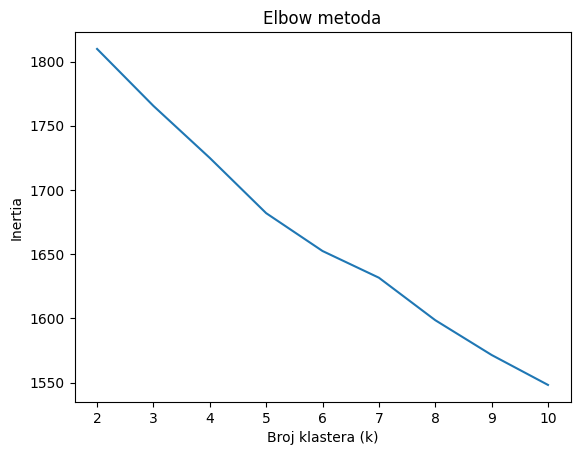

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_svd)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertias)
plt.title("Elbow metoda")
plt.xlabel("Broj klastera (k)")
plt.ylabel("Inertia")
plt.show()

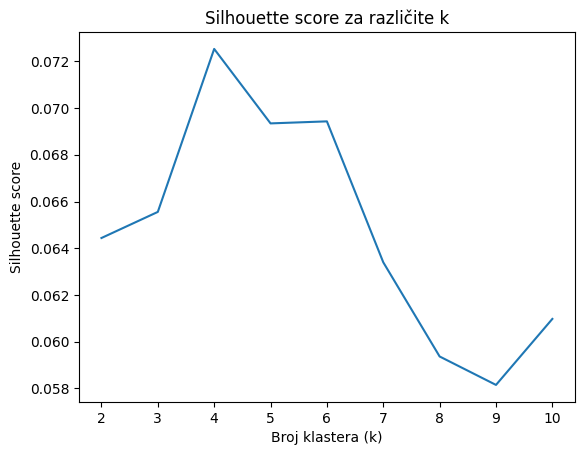

Silhouette scores: [(2, np.float64(0.06443811998149836)), (3, np.float64(0.06555465974260122)), (4, np.float64(0.07253057988853258)), (5, np.float64(0.06934316903786195)), (6, np.float64(0.06943005975706462)), (7, np.float64(0.06339864664915959)), (8, np.float64(0.05936760048045263)), (9, np.float64(0.05815027078057811)), (10, np.float64(0.06097561098482891))]


In [8]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd)
    score = silhouette_score(X_svd, labels)
    sil_scores.append(score)

plt.figure()
plt.plot(K_range, sil_scores)
plt.title("Silhouette score za različite k")
plt.xlabel("Broj klastera (k)")
plt.ylabel("Silhouette score")
plt.show()

print("Silhouette scores:", list(zip(K_range, sil_scores)))

---

## Određivanje optimalnog broja klastera

Za određivanje optimalnog broja klastera primenjene su:

- Elbow metoda
- Silhouette score

Elbow grafikon pokazuje blago "koleno" u intervalu k = 4–5.

Silhouette score dostiže maksimalnu vrednost pri:

k = 4 (0.0725)

## Zaključak:

Za dalju analizu i poređenje algoritama izabran je broj klastera k = 4.

---

In [9]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_svd)

In [11]:
from sklearn.cluster import MiniBatchKMeans

mbk = MiniBatchKMeans(n_clusters=4, random_state=42)
labels_mbk = mbk.fit_predict(X_svd)

In [12]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_svd)

In [13]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(X_svd)

In [14]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.5, min_samples=5)
labels_db = db.fit_predict(X_svd)

In [15]:
def evaluate_clustering(name, labels):
    print(name)
    print("Silhouette:", silhouette_score(X_svd, labels))
    print("Davies-Bouldin:", davies_bouldin_score(X_svd, labels))
    print("Calinski-Harabasz:", calinski_harabasz_score(X_svd, labels))
    print("ARI:", adjusted_rand_score(y_sample, labels))
    print("NMI:", normalized_mutual_info_score(y_sample, labels))
    print("-" * 50)

In [16]:
evaluate_clustering("KMeans", labels_kmeans)
evaluate_clustering("MiniBatchKMeans", labels_mbk)
evaluate_clustering("Agglomerative", labels_agg)
evaluate_clustering("Gaussian Mixture", labels_gmm)

# DBSCAN samo ako ima više od jednog klastera
if len(set(labels_db)) > 1:
    evaluate_clustering("DBSCAN", labels_db)
else:
    print("DBSCAN nije formirao više klastera.")

KMeans
Silhouette: 0.07253057988853258
Davies-Bouldin: 2.996420635359727
Calinski-Harabasz: 306.6532799179406
ARI: 0.02137235685020889
NMI: 0.05618728607654497
--------------------------------------------------
MiniBatchKMeans
Silhouette: 0.06104610756914715
Davies-Bouldin: 3.5900885902415913
Calinski-Harabasz: 256.72896727986125
ARI: 0.015832106315484727
NMI: 0.04060281473665158
--------------------------------------------------
Agglomerative
Silhouette: 0.05373518692270365
Davies-Bouldin: 3.5888021578182325
Calinski-Harabasz: 225.75777350130218
ARI: 0.012528056815189897
NMI: 0.039316075952946436
--------------------------------------------------
Gaussian Mixture
Silhouette: 0.016537472942108142
Davies-Bouldin: 5.073398288726912
Calinski-Harabasz: 157.45705854719643
ARI: 0.06420119338226754
NMI: 0.058498403912931866
--------------------------------------------------
DBSCAN nije formirao više klastera.


---

## Rezultati klasterovanja

Za klasterovanje je korišćen uzorak od 10,000 dokumenata reprezentovanih pomoću TF-IDF vektorizacije i TruncatedSVD redukcije na 100 dimenzija.

Broj klastera određen je na osnovu Elbow i Silhouette analize i postavljen na k = 4.

Evaluirani su sledeći algoritmi:

- KMeans
- MiniBatchKMeans
- Agglomerative Clustering
- Gaussian Mixture Model
- DBSCAN

---

### Interna evaluacija (bez korišćenja labela)

| Algoritam | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|------------|------------|----------------|-------------------|
| KMeans | 0.0725 | 2.9964 | 306.65 |
| MiniBatchKMeans | 0.0610 | 3.5901 | 256.73 |
| Agglomerative | 0.0537 | 3.5888 | 225.76 |
| Gaussian Mixture | 0.0165 | 5.0734 | 157.46 |

Prema internim metrikama, KMeans ostvaruje najbolje rezultate:

- Najviši Silhouette score
- Najniži Davies-Bouldin indeks
- Najviši Calinski-Harabasz indeks

---

### Eksterna evaluacija (poređenje sa pravim labelama)

| Algoritam | ARI | NMI |
|------------|------|------|
| KMeans | 0.0214 | 0.0562 |
| MiniBatchKMeans | 0.0158 | 0.0406 |
| Agglomerative | 0.0125 | 0.0393 |
| Gaussian Mixture | 0.0642 | 0.0585 |

Gaussian Mixture model ostvaruje najvišu vrednost ARI metrike, što ukazuje na nešto bolje poklapanje sa realnom klasnom strukturom.

---

### DBSCAN

DBSCAN algoritam nije uspeo da formira više klastera sa zadatim parametrima, što ukazuje da tekstualni podaci u ovom latentnom prostoru ne pokazuju gustinske strukture pogodne za ovaj algoritam.

---

## Interpretacija rezultata klasterovanja

Rezultati pokazuju da tekstualni podaci nemaju jasno izraženu prirodnu klastersku strukturu.

Silhouette score vrednosti su relativno niske (≈ 0.05–0.07), što ukazuje na značajno preklapanje klastera.

Takođe, niske vrednosti ARI i NMI metrika sugerišu da struktura klastera ne odgovara direktno klasnoj podeli na fake i real vesti.

## Zaključak:

Fake i real vesti se ne razlikuju po jednostavnim globalnim tematskim obrascima, već verovatno po suptilnijim jezičkim karakteristikama koje su pogodnije za nadgledano učenje.

Ovi rezultati potvrđuju da klasifikacija predstavlja pogodniji pristup za rešavanje ovog problema u odnosu na nenadgledano klasterovanje.

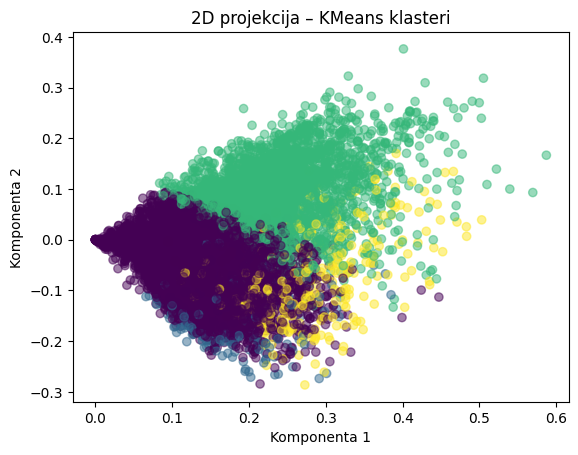

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, alpha=0.5)
plt.title("2D projekcija – KMeans klasteri")
plt.xlabel("Komponenta 1")
plt.ylabel("Komponenta 2")
plt.show()

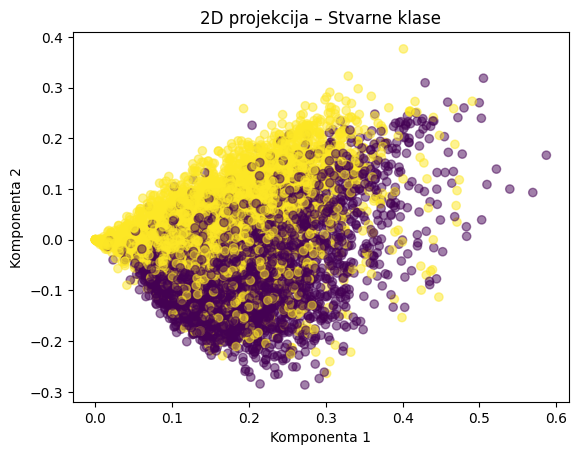

In [18]:
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample, alpha=0.5)
plt.title("2D projekcija – Stvarne klase")
plt.xlabel("Komponenta 1")
plt.ylabel("Komponenta 2")
plt.show()

## Vizuelna analiza klastera

2D projekcija dokumenata omogućava vizuelno poređenje klasterske strukture sa stvarnim klasama.

KMeans klasteri pokazuju određenu strukturu u latentnom prostoru, međutim poređenjem sa stvarnim klasama uočava se značajno preklapanje.

Klasteri ne odgovaraju direktno podeli na fake i real vesti.

Ovakav rezultat sugeriše da klasterovanje prepoznaje globalne tematske ili stilističke obrasce u tekstu, ali ti obrasci ne koreliraju snažno sa klasnom oznakom.

## Zaključak:

Problem razlikovanja fake i real vesti pogodniji je za nadgledano učenje nego za nenadgledano klasterovanje.

---

## Završni zaključci klasterovanja

Eksperimenti klasterovanja pokazali su:

- Nisku vrednost Silhouette metrike (≈ 0.05–0.07)
- Slabo poklapanje klastera sa stvarnim klasama (nizak ARI i NMI)
- Najbolje interne rezultate ostvaruje KMeans
- Gaussian Mixture pokazuje blago bolje poklapanje sa klasama

Rezultati ukazuju da dataset ne poseduje jasno izraženu prirodnu klastersku strukturu koja odgovara klasnoj podeli.

Klasterovanje identifikuje latentne strukture u tekstualnom prostoru, ali one ne reflektuju direktno problem fake/real klasifikacije.

In [19]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(tfidf, "../models/clustering/tfidf_clustering.joblib")
joblib.dump(svd, "../models/clustering/svd_clustering.joblib")

joblib.dump(kmeans, "../models/clustering/kmeans.joblib")
joblib.dump(mbk, "../models/clustering/minibatch_kmeans.joblib")
joblib.dump(agg, "../models/clustering/agglomerative.joblib")
joblib.dump(gmm, "../models/clustering/gaussian_mixture.joblib")

['../models/clustering/gaussian_mixture.joblib']